# 02 — Feature Engineering

Documents each engineered feature, its distribution, and its relationship to the target (goal/no goal).

**Key design choice:** No player or team identity in features. The model learns *what makes a good chance*, not *who takes it*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import VerticalPitch

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/features.parquet")
print(f"Feature matrix: {len(df):,} rows")
print(f"Goal rate: {df['is_goal'].mean():.1%}")
print(f"Features: {df.columns.tolist()}")

Feature matrix: 88,023 rows
Goal rate: 11.1%
Features: ['distance_to_goal', 'angle_to_goal', 'distance_to_nearest_post', 'off_centre', 'is_header', 'is_right_foot', 'is_left_foot', 'is_volley', 'is_half_volley', 'is_lob', 'is_overhead_kick', 'is_backheel', 'is_diving_header', 'is_first_time', 'under_pressure', 'is_one_on_one', 'is_open_goal', 'is_deflected', 'follows_dribble', 'is_redirect', 'is_penalty', 'is_free_kick', 'is_open_play', 'is_from_corner', 'is_counter_attack', 'is_from_free_kick', 'is_from_throw_in', 'is_from_goal_kick', 'is_from_keeper', 'minute', 'is_second_half', 'is_last_15', 'n_defenders_in_cone', 'n_opponents_in_path', 'gk_distance', 'gk_angle_coverage', 'is_goal', 'competition', 'season', 'competition_id', 'season_id', 'match_id', 'player', 'team', 'shot_statsbomb_xg', 'shot_outcome', 'shot_type', 'play_pattern', 'x', 'y']


## Feature summary statistics

In [2]:
import sys
sys.path.insert(0, "..")
from src.features.build_features import FEATURE_COLUMNS

summary = df[FEATURE_COLUMNS].describe().T
summary["missing"] = df[FEATURE_COLUMNS].isna().sum()
summary["missing_pct"] = (summary["missing"] / len(df) * 100).round(1)
print(summary[["count", "mean", "std", "min", "max", "missing_pct"]].to_string())

                            count       mean        std       min         max  missing_pct
distance_to_goal          88023.0  19.180483   8.747756  0.400000   92.800862          0.0
angle_to_goal             88023.0   0.443590   0.275888  0.000000    3.141593          0.0
distance_to_nearest_post  88023.0  17.867719   8.772229  0.300000   91.777993          0.0
off_centre                88023.0   0.200646   0.144413  0.000000    1.000000          0.0
is_header                 88023.0   0.158640   0.365342  0.000000    1.000000          0.0
is_right_foot             88023.0   0.524681   0.499393  0.000000    1.000000          0.0
is_left_foot              88023.0   0.313759   0.464022  0.000000    1.000000          0.0
is_volley                 88023.0   0.197108   0.397817  0.000000    1.000000          0.0
is_half_volley            88023.0   0.133056   0.339637  0.000000    1.000000          0.0
is_lob                    88023.0   0.009975   0.099374  0.000000    1.000000          0.0

## Location features: distance, angle, and goal rate

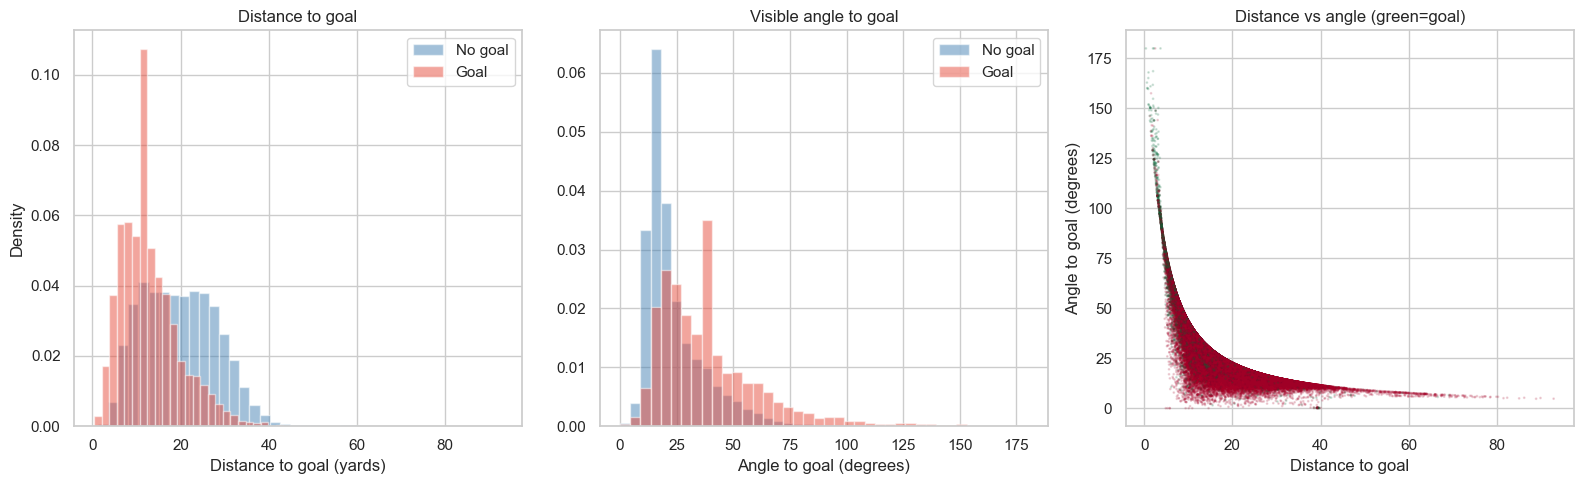

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distance distribution by outcome
for label, group in df.groupby("is_goal"):
    axes[0].hist(group["distance_to_goal"], bins=40, alpha=0.5, density=True,
                 label="Goal" if label else "No goal", color="#e74c3c" if label else "steelblue")
axes[0].set_xlabel("Distance to goal (yards)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distance to goal")
axes[0].legend()

# Angle distribution by outcome
for label, group in df.groupby("is_goal"):
    axes[1].hist(np.degrees(group["angle_to_goal"]), bins=40, alpha=0.5, density=True,
                 label="Goal" if label else "No goal", color="#e74c3c" if label else "steelblue")
axes[1].set_xlabel("Angle to goal (degrees)")
axes[1].set_title("Visible angle to goal")
axes[1].legend()

# Distance vs angle coloured by goal rate
non_pen = df[df["is_penalty"] == 0]
axes[2].scatter(non_pen["distance_to_goal"], np.degrees(non_pen["angle_to_goal"]),
                c=non_pen["is_goal"], cmap="RdYlGn", s=1, alpha=0.15)
axes[2].set_xlabel("Distance to goal")
axes[2].set_ylabel("Angle to goal (degrees)")
axes[2].set_title("Distance vs angle (green=goal)")

plt.tight_layout()
plt.show()

## Shot-level features: goal rate by category

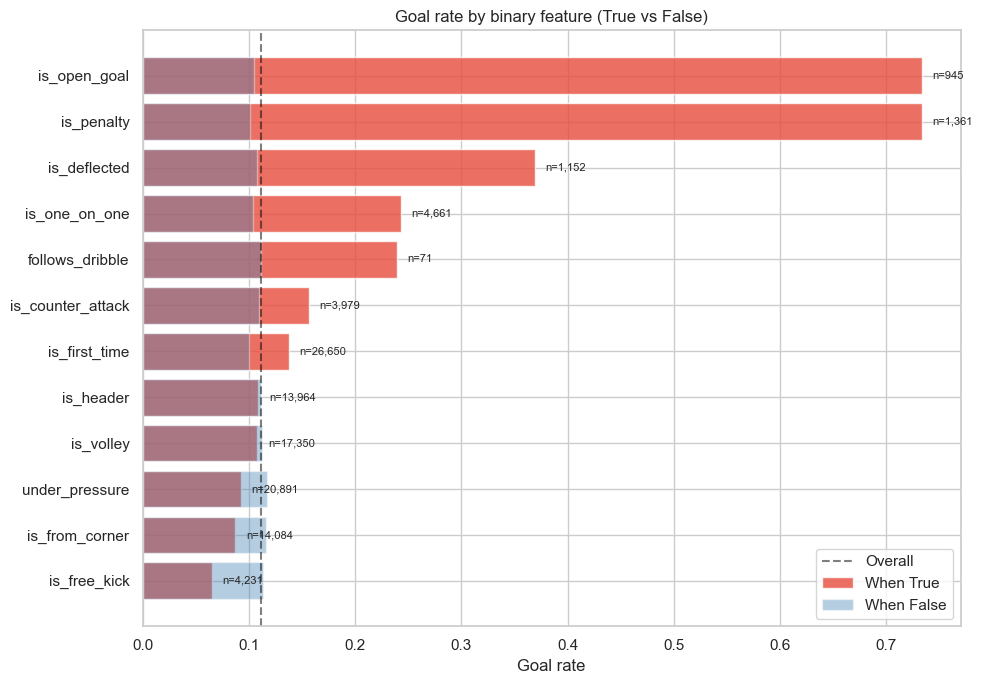

In [4]:
binary_features = [
    "is_header", "is_volley", "is_first_time", "under_pressure",
    "is_one_on_one", "is_open_goal", "is_deflected", "follows_dribble",
    "is_penalty", "is_free_kick", "is_counter_attack", "is_from_corner",
]

goal_rates = []
for feat in binary_features:
    rate_1 = df.loc[df[feat] == 1, "is_goal"].mean()
    rate_0 = df.loc[df[feat] == 0, "is_goal"].mean()
    count_1 = (df[feat] == 1).sum()
    goal_rates.append({"feature": feat, "goal_rate_true": rate_1, "goal_rate_false": rate_0, "count_true": count_1})

gr = pd.DataFrame(goal_rates).sort_values("goal_rate_true", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(gr))
ax.barh(y_pos, gr["goal_rate_true"], color="#e74c3c", alpha=0.8, label="When True")
ax.barh(y_pos, gr["goal_rate_false"], color="steelblue", alpha=0.4, label="When False")
ax.set_yticks(y_pos)
ax.set_yticklabels(gr["feature"])
ax.set_xlabel("Goal rate")
ax.set_title("Goal rate by binary feature (True vs False)")
ax.axvline(df["is_goal"].mean(), color="black", linestyle="--", alpha=0.5, label="Overall")
ax.legend()

# Add count annotations
for i, row in enumerate(gr.itertuples()):
    ax.text(row.goal_rate_true + 0.01, i, f"n={row.count_true:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Freeze frame features: defenders and goalkeeper

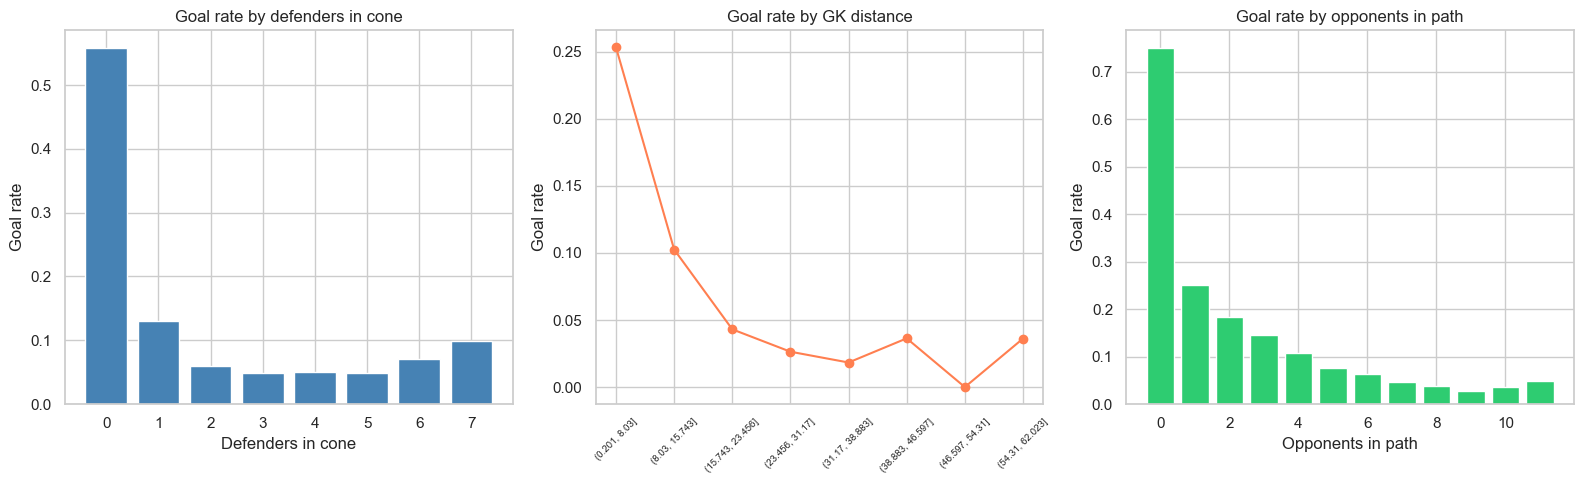

GK distance available: 86,733 / 88,023 (98.5%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Defenders in cone vs goal rate
cone_rates = df.groupby("n_defenders_in_cone")["is_goal"].agg(["mean", "count"])
cone_rates = cone_rates[cone_rates["count"] >= 50]
axes[0].bar(cone_rates.index, cone_rates["mean"], color="steelblue")
axes[0].set_xlabel("Defenders in cone")
axes[0].set_ylabel("Goal rate")
axes[0].set_title("Goal rate by defenders in cone")

# GK distance vs goal rate
valid_gk = df.dropna(subset=["gk_distance"])
valid_gk["gk_dist_bin"] = pd.cut(valid_gk["gk_distance"], bins=15)
gk_rates = valid_gk.groupby("gk_dist_bin", observed=True)["is_goal"].agg(["mean", "count"])
gk_rates = gk_rates[gk_rates["count"] >= 50]
axes[1].plot(range(len(gk_rates)), gk_rates["mean"], marker="o", color="coral")
axes[1].set_xticks(range(len(gk_rates)))
axes[1].set_xticklabels([str(x) for x in gk_rates.index], rotation=45, fontsize=7)
axes[1].set_ylabel("Goal rate")
axes[1].set_title("Goal rate by GK distance")

# Opponents in path vs goal rate
path_rates = df.groupby("n_opponents_in_path")["is_goal"].agg(["mean", "count"])
path_rates = path_rates[path_rates["count"] >= 50]
axes[2].bar(path_rates.index, path_rates["mean"], color="#2ecc71")
axes[2].set_xlabel("Opponents in path")
axes[2].set_ylabel("Goal rate")
axes[2].set_title("Goal rate by opponents in path")

plt.tight_layout()
plt.show()

print(f"GK distance available: {valid_gk.shape[0]:,} / {len(df):,} ({valid_gk.shape[0]/len(df):.1%})")

## Feature correlations

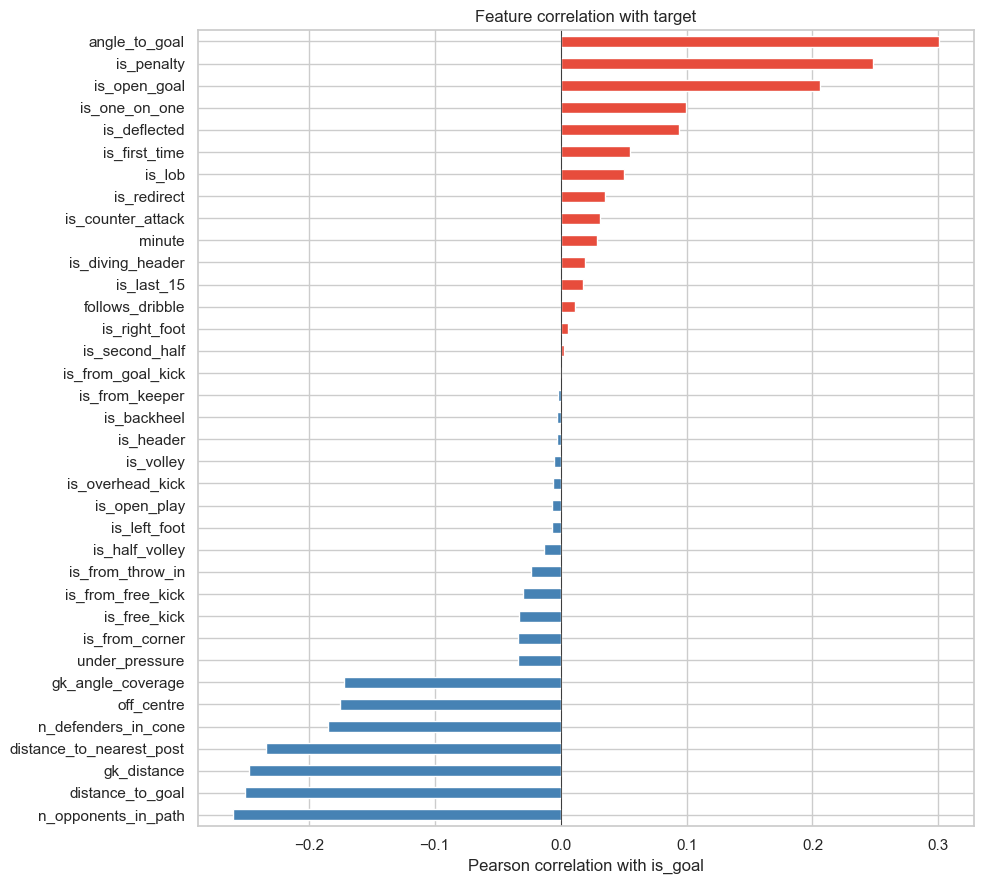

In [6]:
# Correlation with target
corrs = df[FEATURE_COLUMNS + ["is_goal"]].corr()["is_goal"].drop("is_goal").sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#e74c3c" if v > 0 else "steelblue" for v in corrs]
corrs.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Pearson correlation with is_goal")
ax.set_title("Feature correlation with target")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## Shot map coloured by key features

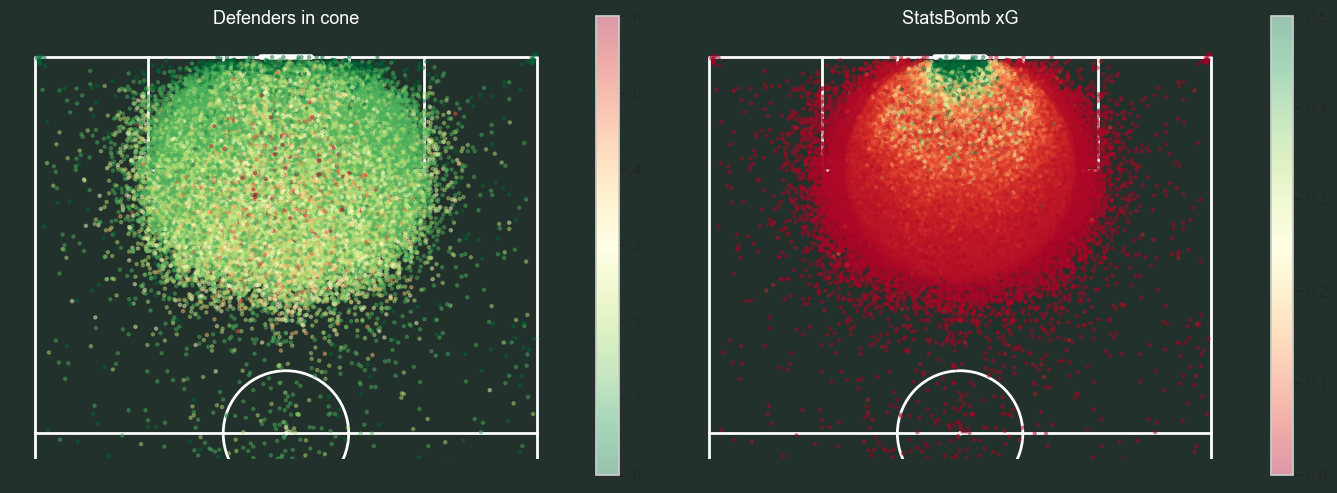

In [7]:
non_pen = df[df["is_penalty"] == 0].copy()

pitch = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#22312b", line_color="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Coloured by defenders in cone
pitch.draw(ax=axes[0])
sc = pitch.scatter(non_pen["x"], non_pen["y"], c=non_pen["n_defenders_in_cone"],
                   ax=axes[0], s=5, cmap="RdYlGn_r", vmin=0, vmax=6, alpha=0.4)
axes[0].set_title("Defenders in cone", color="white", fontsize=13)
plt.colorbar(sc, ax=axes[0], shrink=0.6)

# Coloured by StatsBomb xG (for comparison)
pitch.draw(ax=axes[1])
sc2 = pitch.scatter(non_pen["x"], non_pen["y"], c=non_pen["shot_statsbomb_xg"],
                    ax=axes[1], s=5, cmap="RdYlGn", vmin=0, vmax=0.5, alpha=0.4)
axes[1].set_title("StatsBomb xG", color="white", fontsize=13)
plt.colorbar(sc2, ax=axes[1], shrink=0.6)

fig.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

## Key takeaways

- **36 features** engineered from raw StatsBomb data
- **Distance and angle** are the most correlated with scoring — expected, and validates our calculations
- **One-on-one and open goal** have very high goal rates (~35-40% vs ~10% baseline)
- **Headers** have lower conversion than foot shots — makes sense
- **Defenders in cone** shows clear negative relationship — more defenders = fewer goals
- **GK distance** shows non-linear pattern — very close GK = low conversion (good positioning), very far GK = higher conversion (out of position)
- **Penalties** are a distinct category (~76% conversion) — model needs to handle these separately or the feature will dominate
- **No player/team identity** — deliberately excluded. We'll bring these back at analysis time to find over/underperformers